# Weekly Project 06 - 3D Point Cloud Processing 2

Today we will continue the work from Monday.
We will follow the style of last week.

Weekly project:

- You will need to implement your own k-means algorithm. You are not allowed to use the implementation in `sklearn`.
- It should be able to cluster each of the different figures.
- Extend your k-means algorithm so that it finds the optimal number of clusters.

## Challenge

- Implement the mean shift clustering algorithm.

## Weekly Project 06 - Start Here

We set Open3D's sampling seed and the k-means seed to `0`. Running the notebook from the top therefore uses the same points and initial centres.

In [1]:
import numpy as np
import open3d as o3d
import copy
import matplotlib.pyplot as plt

def draw_labels_on_model(pcl, labels):
    cmap = plt.get_cmap("tab20")
    pcl_temp = copy.deepcopy(pcl)
    max_label = labels.max()
    colors = cmap(labels / (max_label if max_label > 0 else 1))
    colors[labels < 0] = 0
    pcl_temp.colors = o3d.utility.Vector3dVector(colors[:, :3])
    o3d.visualization.draw_geometries([pcl_temp])

d = 4
mesh = o3d.geometry.TriangleMesh.create_tetrahedron().translate((-d, 0, 0))
mesh += o3d.geometry.TriangleMesh.create_octahedron().translate((0, 0, 0))
mesh += o3d.geometry.TriangleMesh.create_icosahedron().translate((d, 0, 0))
mesh += o3d.geometry.TriangleMesh.create_torus().translate((-d, -d, 0))
mesh += o3d.geometry.TriangleMesh.create_mobius(twists=1).translate((0, -d, 0))
mesh += o3d.geometry.TriangleMesh.create_mobius(twists=2).translate((d, -d, 0))

# Fix the sampled points each time this cell is run.
o3d.utility.random.seed(0)
point_cloud = mesh.sample_points_uniformly(int(1e3))


### K-means Algorithm

We implemented `kmeans` using NumPy and one random initialisation. It places `k` centres uniformly inside the bounding box of the point cloud, assigns each point to its nearest centre, and moves each non-empty centre to the mean of its assigned points. An empty cluster keeps its previous centre. These steps repeat until the centres change very little or the iteration limit of `n_iter=200` is reached.

`dists` stores the Euclidean distance from every point to every centre. Its shape is `(N, k)`, where `N` is the number of points and `k` is the number of centres. Each row contains one point's distances to all centres, so `dists[i, j]` is the distance from point `i` to centre `j`.

`np.argmin(dists, axis=1)` finds the nearest centre for each point.

The function returns one cluster label per point. The default `seed = 0` makes the initial centres repeatable for the same input points.

In [2]:
def kmeans(points, k, n_iter=200, seed=0):

    rng = np.random.default_rng(seed)  
    centers = rng.uniform(points.min(axis=0), points.max(axis=0), size=(k, points.shape[1]))

    for _ in range(n_iter):
        dists = np.linalg.norm(points[:, None, :] - centers[None, :, :], axis=2)
        labels = np.argmin(dists, axis=1)
        new_centers = np.array([points[labels == q].mean(axis=0) if np.any(labels == q) else centers[q] for q in range(k)])
        if np.allclose(new_centers, centers):
            break
        centers = new_centers
    return labels


We convert the point cloud to a NumPy array with one `(x, y, z)` row per point, call `kmeans` with `k = 6`, and display the result with a colour for each cluster. We choose six clusters to match the six geometric figures used to generate the point cloud.

In [3]:
# Convert the point cloud to a NumPy array with one (x, y, z) row per point.
xyz = np.asarray(point_cloud.points)
k = 6
labels = kmeans(xyz, k)
draw_labels_on_model(point_cloud, labels)


#### Results

The saved screenshot shows six colours, with each figure assigned to a separate cluster. For this sampled scene, the fixed choice of `k = 6` therefore separates all six figures.

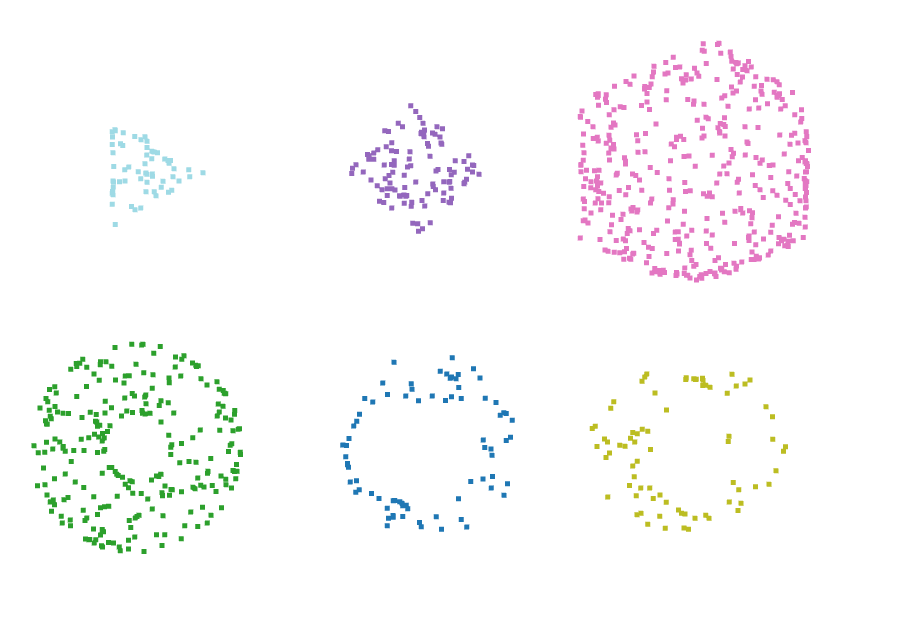

### Extended K-means Algorithm for the Optimal Number of Clusters

We extend the fixed-`k` example by trying values from `1` to `10` on the same point cloud. For each result, we calculate the distortion as the sum of squared distances from points to their cluster means, and save the labels in `labels_by_k`.

We estimate the elbow by normalising the tested `k` values and the reduction in distortion.

`y - x` measures the gap between the normalised improvement curve and the line joining its endpoints. The largest gap selects `best_k`. If the endpoint distortions are equal, the code selects the first tested value. We plot the distortion curve and display the saved clustering for the selected value.

The elbow is a heuristic for the point where adding more clusters gives a smaller improvement. It estimates a suitable cluster count from this curve, rather than guaranteeing an optimal count for the individual figures.

Elbow estimate: k = 2


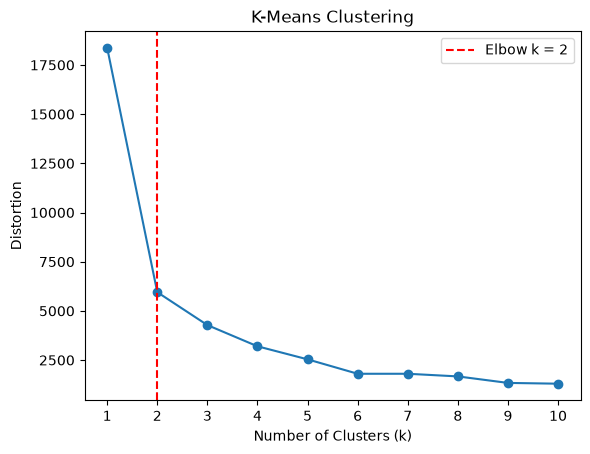

In [4]:
# Use the same point cloud as in the fixed-k example above.
k_values = range(1, 11)
distortions = []
labels_by_k = []

for k in k_values:
    labels = kmeans(xyz, k)
    labels_by_k.append(labels)

    # Distortion is the sum of squared distances to each cluster's mean.
    distortion = 0
    for label in np.unique(labels):
        cluster_points = xyz[labels == label]
        center = cluster_points.mean(axis=0)
        distortion += np.sum((cluster_points - center) ** 2)
    distortions.append(distortion)

# Normalise the curve and find the point furthest above its endpoint line.
if distortions[0] == distortions[-1]:
    best_index = 0
else:
    x = np.linspace(0, 1, len(k_values))
    y = (distortions[0] - np.array(distortions)) / (distortions[0] - distortions[-1])
    best_index = int(np.argmax(y - x))
best_k = k_values[best_index]
labels = labels_by_k[best_index]
print(f"Elbow estimate: k = {best_k}")

plt.figure()
plt.plot(k_values, distortions, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"Elbow k = {best_k}")
plt.xticks(k_values)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Distortion")
plt.title("K-Means Clustering")
plt.legend()
plt.show()

draw_labels_on_model(point_cloud, labels)


#### Results

The saved output selects `k = 2`, although the scene contains six figures. The screenshot shows several figures grouped together and the lower middle figure split between the two clusters. The automatic selection therefore does not recover the six individual figures in this run.

![kmeans algo2.png](<attachment:kmeans algo2.png>)
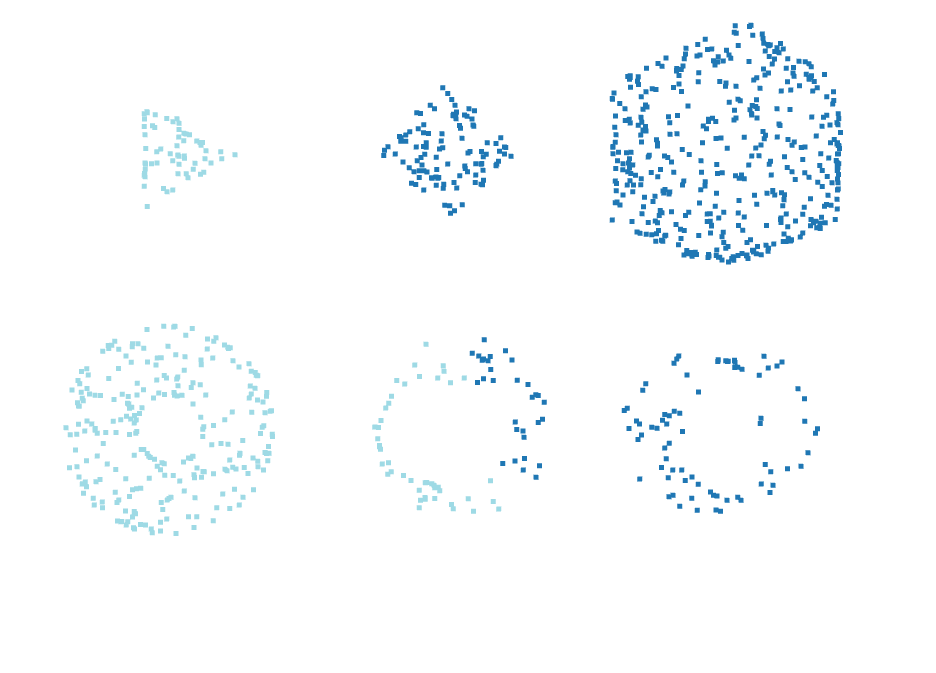

### Challenge - Mean Shift Clustering

We implemented `mean_shift` with a Gaussian kernel. One moving point starts at each input point. In each iteration, it moves to the weighted mean of the original input points, with closer points receiving larger weights. 

`bandwidth` controls how quickly the weights decrease with distance.

The moving points are processed in batches of `256`. Iteration stops when the largest movement is at most `tol = 1e-3`, or after `100` iterations. The final positions are called modes.

We group modes that are within `merge_distance` of an existing centre. When a mode joins a cluster, its centre is updated to the mean of the modes added so far. The default merge distance is half the bandwidth. The function returns one label per input point and the cluster centres. The number of clusters follows from the modes instead of a supplied `k`.

In [ ]:
def mean_shift(points, bandwidth, max_iter=100, tol=1e-3,
               merge_distance=None, batch_size=256):
    X = np.asarray(points, dtype=float)

    if merge_distance is None:
        merge_distance = bandwidth / 2

    # Start one moving point at each input point.
    modes = X.copy()
    n_points = len(X)

    for _ in range(max_iter):
        updated_modes = np.empty_like(modes)

        # Process in batches to limit memory use.
        for start in range(0, n_points, batch_size):
            stop = min(start + batch_size, n_points)
            current = modes[start:stop]

            # Distance from these moving points to every input point.
            delta = current[:, None, :] - X[None, :, :]
            distances_sq = np.sum(delta ** 2, axis=2)

            # Gaussian kernel: closer points have more influence.
            weights = np.exp(
                -distances_sq / (2 * bandwidth ** 2)
            )

            # Move each point to its weighted mean.
            updated_modes[start:stop] = (
                weights @ X
            ) / weights.sum(axis=1, keepdims=True)

        movement = np.linalg.norm(updated_modes - modes, axis=1).max()
        modes = updated_modes

        if movement <= tol:
            break

    # Merge points whose final modes are close together.
    labels = np.full(n_points, -1, dtype=int)
    centers = []
    counts = []

    for i, mode in enumerate(modes):
        if centers:
            distances = np.linalg.norm(np.asarray(centers) - mode, axis=1)
            nearest = np.argmin(distances)

            if distances[nearest] <= merge_distance:
                labels[i] = nearest
                counts[nearest] += 1
                centers[nearest] += (mode - centers[nearest]) / counts[nearest]
                continue

        labels[i] = len(centers)
        centers.append(mode.copy())
        counts.append(1)

    return labels, np.asarray(centers)

We build an Open3D KD-tree and find each point's 20th nearest neighbour. We request `21` neighbours because the point itself is included. Open3D returns squared distances, so we take the square root of the last returned distance.

These distances form a distribution. We choose the bandwidth `h` as its 90th percentile using `np.percentile`. This gives about 90% of the points at least 20 other points within distance `h`. We pass it to `mean_shift`, which uses `h` as the Gaussian scale and half of `h` as the merge distance.

In [ ]:
points = np.asarray(point_cloud.points)
tree = o3d.geometry.KDTreeFlann(point_cloud)
k_neighbors = 20
neighbor_distances = []

for point in points:
    # Request one extra neighbour because the point itself is included.
    _, _, distances_sq = tree.search_knn_vector_3d(point, k_neighbors + 1)
    neighbor_distances.append(np.sqrt(distances_sq[-1]))

automatic_bandwidth = np.percentile(neighbor_distances, 90)
labels, centers = mean_shift(points, bandwidth=automatic_bandwidth)

print(f"Automatic bandwidth: {automatic_bandwidth:.4f}")
print("Clusters found:", len(centers))
draw_labels_on_model(point_cloud, labels)

Automatic bandwidth: 0.8581
Clusters found: 8
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 


#### Results

With seed `0`, the 90th-percentile rule gives a bandwidth of `0.8581` and finds eight clusters for the six-figure scene.

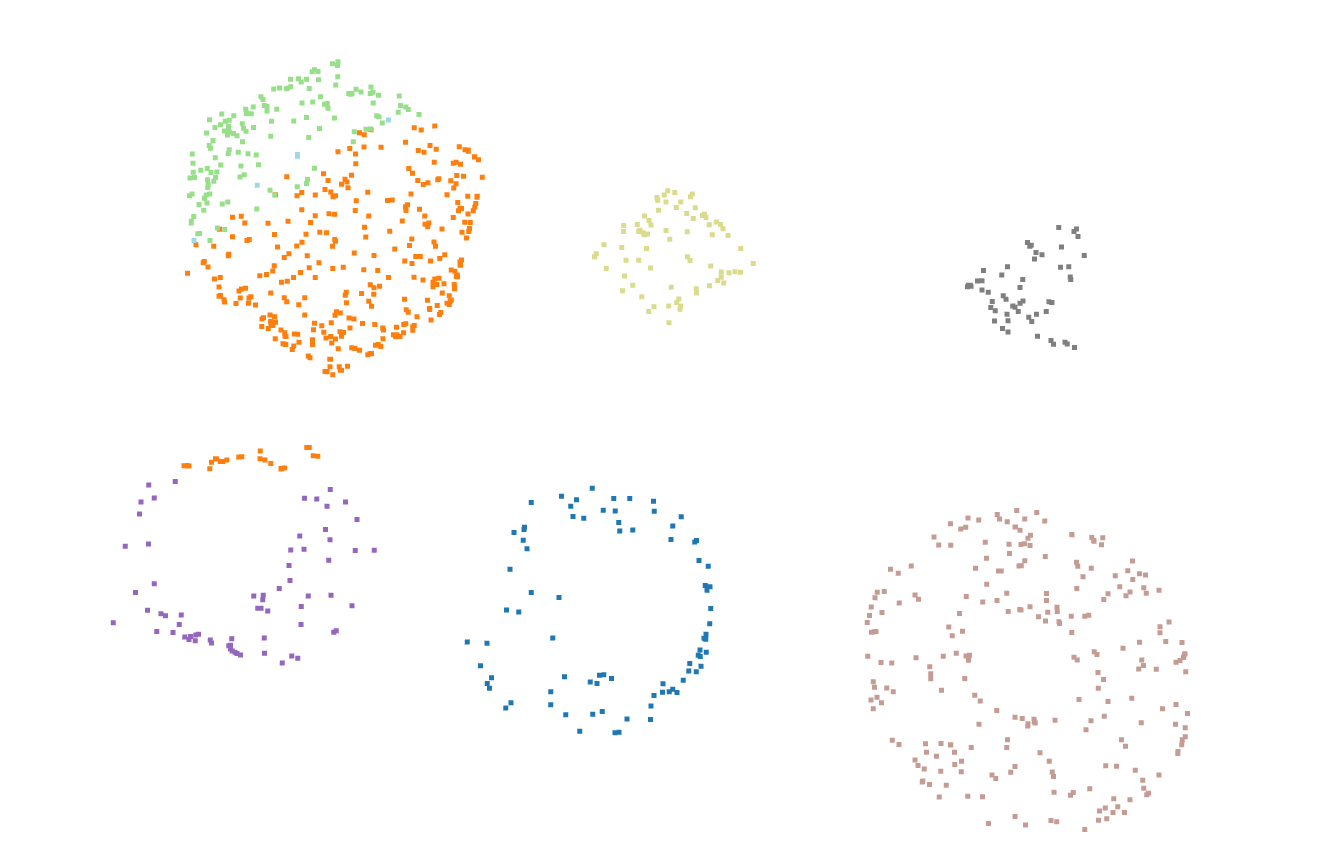

## Declaration of AI Usage

- We used AI to help us review the code, check reproducibility and refine the documentation.